In [2]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
from sklearn.preprocessing import normalize, StandardScaler
from sklearn.model_selection import train_test_split
from __future__ import print_function
import time
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import roc_auc_score

In [3]:
file_loc = "C:/Users/LAPTOP/Downloads/creditcard.csv"
transactions_data = pd.read_csv(file_loc)
print("There are %.2f observations in the credit card fraud dataset" % len(transactions_data))
print("There are %.2f variables in the dataset" % len(transactions_data.columns))

There are 284807.00 observations in the credit card fraud dataset
There are 31.00 variables in the dataset


In [4]:
transactions_data.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [5]:
n_replicas = 5
large_transac_data = pd.DataFrame(np.repeat(transactions_data.values, n_replicas, axis=0), columns=transactions_data.columns)
print("There are %.2f observations in the credit card fraud dataset" % len(large_transac_data ))
print("There are %.2f variables in the dataset" % len(large_transac_data.columns))
large_transac_data.head(10)

There are 1424035.00 observations in the credit card fraud dataset
There are 31.00 variables in the dataset


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
1,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
2,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
3,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
4,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
5,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
6,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
7,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
8,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
9,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0


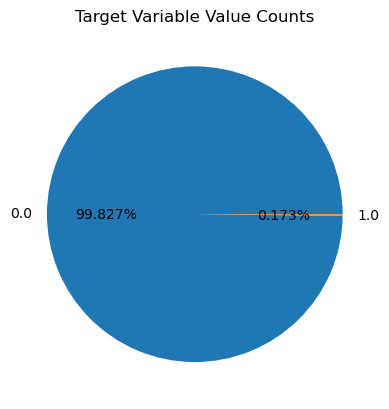

In [6]:
label = large_transac_data.Class.unique()
size = large_transac_data.Class.value_counts().values
fig, ax = plt.subplots()
ax.pie(size, labels=label, autopct='%1.3f%%')
ax.set_title("Target Variable Value Counts")
plt.show()

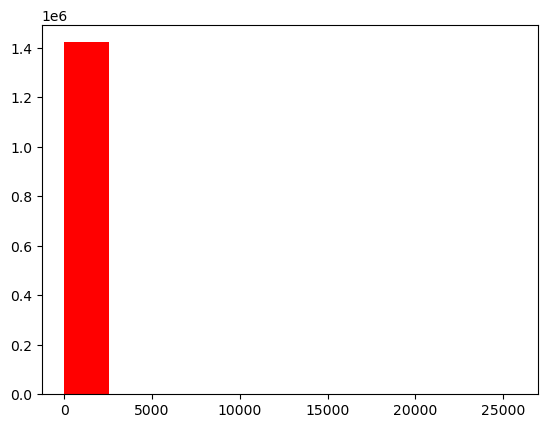

Minimum amount value is  0.0
Maximum amount value is  25691.16
90% of the transactions have an amount less or equal than  203.0


In [7]:
plt.hist(large_transac_data.Amount.values, 10, histtype='bar', facecolor='red')
plt.show()
print("Minimum amount value is ", np.min(large_transac_data.Amount.values))
print("Maximum amount value is ", np.max(large_transac_data.Amount.values))
print("90% of the transactions have an amount less or equal than ", np.percentile(large_transac_data.Amount.values, 90))

In [8]:
large_transac_data.iloc[:, 1:30] = StandardScaler().fit_transform(large_transac_data.iloc[:, 1:30])
transactions_matrix = large_transac_data.values
x_mat = transactions_matrix[:, 1:30]
y_mat = transactions_matrix[:, 30]
x_mat = normalize(x_mat, norm ='l1')
x_train, x_test, y_train, y_test = train_test_split(x_mat, y_mat, test_size=0.3, random_state=42, stratify=y_mat)
w_train = compute_sample_weight("balanced", y_train)
print("X shape:",x_mat.shape, "Y shape:", y_mat.shape)

X shape: (1424035, 29) Y shape: (1424035,)


In [9]:
from sklearn.tree import DecisionTreeClassifier
sklearn_decision =  DecisionTreeClassifier(max_depth=4, random_state=35)
start_time = time.time()
sklearn_decision.fit(x_train, y_train, sample_weight = w_train)
sklearn_time = time.time() - start_time
print("[Scikit-Learn]Training time (s): {0:.5f}".format(sklearn_time))

[Scikit-Learn]Training time (s): 99.85853


In [10]:
from snapml import DecisionTreeClassifier
snap_decision = DecisionTreeClassifier(max_depth = 4, random_state = 35, n_jobs = 4)
then = time.time()
snap_decision.fit(x_train, y_train, sample_weight = w_train)
time_change = time.time() - then
print("The time it took to train is {0:.5f}s".format(time_change))

The time it took to train is 8.21343s


In [11]:
speedup_train = sklearn_time/time_change
print("[Decision Tree Classifier] SnapML {0:.2f}times is faster than ScikitLearn".format(speedup_train))
predict_skd = sklearn_decision.predict_proba(x_test)[:,1]
sklearn_roc_auc = roc_auc_score(y_test, predict_skd)
print('[Scikit-Learn] ROC-AUC score: {0:.3f}'.format(sklearn_roc_auc))
predict_snap = snap_decision.predict_proba(x_test)[:,1]
snap_roc_auc = roc_auc_score(y_test, predict_snap)
print('[Snap ML] ROC-AUC score: {0:.3f}'.format(snap_roc_auc))

[Decision Tree Classifier] SnapML 12.16times is faster than ScikitLearn
[Scikit-Learn] ROC-AUC score: 0.967
[Snap ML] ROC-AUC score: 0.966


In [22]:
from snapml import SupportVectorMachine
sv_machine = SupportVectorMachine(class_weight = "balanced", random_state = 31, n_jobs = 4, fit_intercept = False)
current_time = time.time()
sv_model = sv_machine.fit(x_train, y_train)
time_delta = time.time() - current_time
print("The time it took to train the model is {0:.5f}s".format(time_delta))

The time it took to train the model is 6.56375s


In [23]:
from sklearn.svm import LinearSVC
sklearn_machine = LinearSVC(class_weight = "balanced", random_state = 31,loss = "hinge", fit_intercept = False)
initial_skm_time = time.time()
sklearn_linear = sklearn_machine.fit(x_train, y_train)
final_skmt = time.time()
print("The time it took to train the sklearnmodel is {0:.5f}s".format(final_skmt))

The time it took to train the sklearnmodel is 1734074591.24501s


C:\Users\LAPTOP\anaconda3\lib\site-packages\sklearn\svm\_base.py:1244: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


In [24]:
speedup_train = final_skmt/time_delta
print("[Support Vector Machine] SnapML {0:.6f}times is faster than ScikitLearn".format(speedup_train))
supportv_pred = sv_model.decision_function(x_test)
svm_roc_auc = roc_auc_score(y_test, supportv_pred)
print('[Snap ML] ROC-AUC score: {0:.3f}'.format(svm_roc_auc))
sklearn_svc_pred = sklearn_linear.decision_function(x_test)
svc_roc_auc = roc_auc_score(y_test, sklearn_svc_pred)
print('[Scikit-Learn] ROC-AUC score: {0:.3f}'.format(svc_roc_auc))


[Support Vector Machine] SnapML 264189806.656506times is faster than ScikitLearn
[Snap ML] ROC-AUC score: 0.981
[Scikit-Learn] ROC-AUC score: 0.981
